In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
#loading last week's model
from tensorflow.keras.models import load_model
model_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/models/autoencoder_v1.keras"
model = load_model(model_path)

In [5]:
#defining input/output layers
inputs = model.input
outputs = model.get_layer("LSTM_Encoder").output

In [8]:
#defining a stripped model
from tensorflow.keras.models import Model
encoder_model = Model(inputs=inputs, outputs=outputs)

In [7]:
#import X_scaled from last week
import numpy as np
file_path = "/content/drive/MyDrive/Lion-Biologging-SoS'26/X_scaled_clean.npy"
X_scaled = np.load(file_path)
print(X_scaled.shape)

(15952, 24, 8)


In [9]:
results = encoder_model.predict(X_scaled)
print(results.shape)

499/499 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
(15952, 16)


In [13]:
#preparing dataframe
import pandas as pd

col_name = ["Latent_" + str(i) for i in range(1,results.shape[1]+1)] #latent for hidden features
df = pd.DataFrame(results, columns=col_name)
df.head()

,Latent_1,Latent_2,Latent_3,Latent_4,Latent_5,Latent_6,Latent_7,Latent_8,Latent_9,Latent_10,Latent_11,Latent_12,Latent_13,Latent_14,Latent_15,Latent_16
0,-0.754470,-0.198276,0.322154,-0.545383,-0.029061,0.009075,-0.918030,0.906822,0.209343,0.205516,0.733164,-0.445039,0.591737,0.834261,0.020618,-0.066779
1,-0.782490,-0.142967,0.343001,-0.564784,-0.026751,-0.105019,-0.914007,0.914952,0.208197,0.104809,0.758690,-0.485803,0.600891,0.846750,-0.028976,0.187342
2,-0.793302,-0.132062,0.393537,-0.567881,0.001474,-0.181779,-0.910082,0.910313,0.247678,-0.006925,0.771090,-0.460064,0.631267,0.847546,-0.079345,0.233095
3,-0.818835,-0.084772,0.413530,-0.557722,0.006919,-0.273707,-0.907049,0.899244,0.287331,-0.125050,0.782668,-0.445519,0.663733,0.848722,-0.130131,0.162343
4,-0.836118,-0.092660,0.365601,-0.573552,-0.017751,-0.296088,-0.909539,0.898242,0.279936,-0.270956,0.786705,-0.485725,0.678921,0.849422,-0.209711,0.267429


In [17]:
#compressing our data from 16 componenets to 2 components using PCA(linear)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
pca_results = pca.fit_transform(df)

In [20]:
print(pca.explained_variance_ratio_)

[0.4582262  0.29826027]


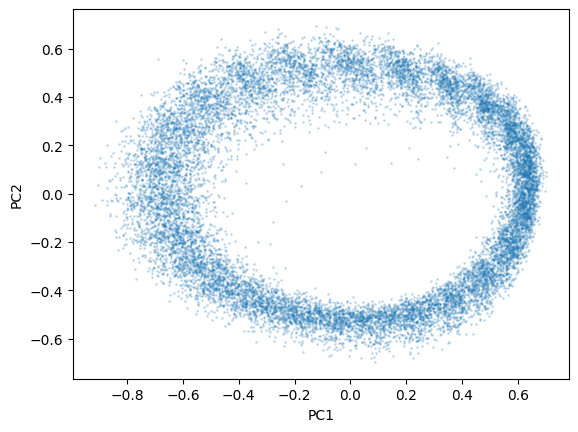

In [32]:
#visualising the PC1 v PC2 plot
import matplotlib.pyplot as plt
plt.scatter(pca_results[:,0], pca_results[:,1],s=1,alpha=0.2) # s, alpha to prevent overplotting(too much overlapping)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

donut/circle shape indicated lion's 24hr circadian rhythm

In [31]:
#using t-SNE which is better than PCA because t-SNE is non linear . and t-SNE also makes small clusters of similar data
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2,perplexity=50,random_state=7)
tsne_results = tsne.fit_transform(df)


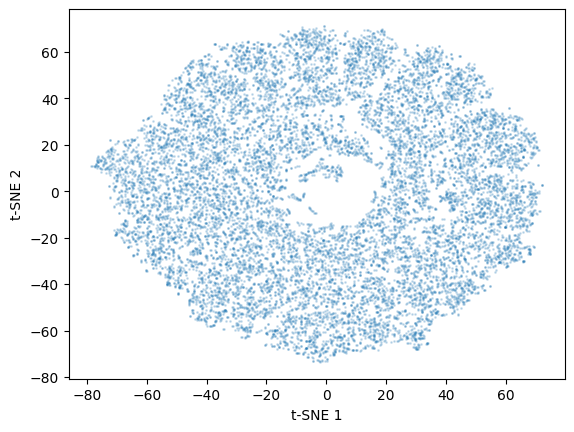

In [30]:
plt.scatter(tsne_results[:,0], tsne_results[:,1],s=1,alpha=0.2) # s, alpha to prevent overplotting(too much overlapping)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [33]:
#saving files
np.save("/content/drive/MyDrive/Lion-Biologging-SoS'26/tsne_results_2d.npy",tsne_results)
np.save("/content/drive/MyDrive/Lion-Biologging-SoS'26/X_latent_16d.npy",df)